<a href="https://colab.research.google.com/github/mdmehedihasan/diffusion_feb_25/blob/intro_diffusion/Stable_Diffusion_Model_Parameter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.7 MB/s eta 0:00:00


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

...

unet/config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

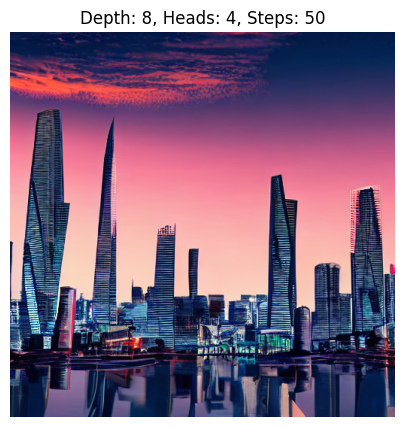

  0%|          | 0/50 [00:00<?, ?it/s]

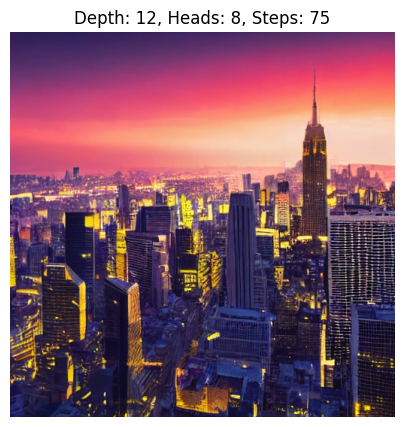

  0%|          | 0/50 [00:00<?, ?it/s]

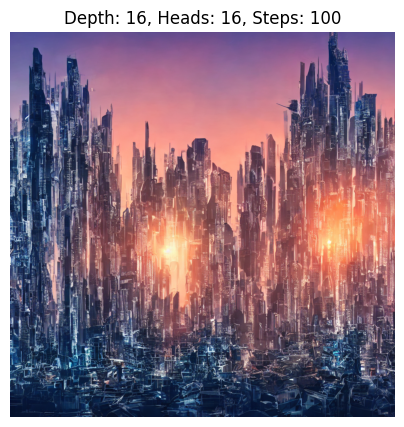

   Model Depth  Attention Heads  Sampling Steps  Latent Resolution  \
0            8                4              50                512   
1           12                8              75                512   
2           16               16             100               1024   

   Inference Time (s)  Memory Usage (GB)  
0           24.085594           5.139855  
1           23.063179           5.139855  
2          169.598397           5.140587  


In [1]:
# Install necessary libraries
!pip install diffusers transformers accelerate torch torchvision numpy matplotlib -q

import torch
import time
import numpy as np
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline

# Load Stable Diffusion model
device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
pipe.to(device)

# Function to test inference time by varying parameters
def measure_performance(model_depth, attention_heads, sampling_steps, latent_resolution):
    # Modify model parameters dynamically
    pipe.unet.config.block_out_channels = [256] * model_depth  # Adjust model depth
    pipe.unet.config.cross_attention_dim = 64 * attention_heads  # Adjust attention heads
    pipe.scheduler.set_timesteps(sampling_steps)  # Adjust sampling steps

    # Generate image and measure time
    prompt = "A futuristic city skyline at sunset"
    start_time = time.time()
    image = pipe(prompt, height=latent_resolution, width=latent_resolution).images[0]
    end_time = time.time()

    inference_time = end_time - start_time
    memory_usage = torch.cuda.memory_allocated(device) / (1024**3) if device == "cuda" else "N/A"

    return inference_time, memory_usage, image

# Experiment with different parameter values
configs = [
    {"model_depth": 8, "attention_heads": 4, "sampling_steps": 50, "latent_resolution": 512},
    {"model_depth": 12, "attention_heads": 8, "sampling_steps": 75, "latent_resolution": 512},
    {"model_depth": 16, "attention_heads": 16, "sampling_steps": 100, "latent_resolution": 1024},
]

results = []
for config in configs:
    time_taken, memory_used, img = measure_performance(**config)
    results.append([config["model_depth"], config["attention_heads"], config["sampling_steps"],
                    config["latent_resolution"], time_taken, memory_used])

    # Display generated image
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Depth: {config['model_depth']}, Heads: {config['attention_heads']}, Steps: {config['sampling_steps']}")
    plt.show()

# Print results in tabular format
import pandas as pd
df = pd.DataFrame(results, columns=["Model Depth", "Attention Heads", "Sampling Steps", "Latent Resolution", "Inference Time (s)", "Memory Usage (GB)"])
print(df)
